# NASA C-MAPSS FD001 — Final RUL Model Evaluation

**Author:** Pallavi 

---

## Objective

In this notebook, I will evaluate the selected Linear Regression model on the completely unseen FD001 test engines.

The model was selected using the validation results from the previous experiments.

The final evaluation will use the actual RUL values provided for the test engines to measure how well the model generalizes to unseen engine data.

In [1]:
# Importing required libraries

import sys
import pandas as pd
import numpy as np

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sys.path.append("../")

from src.preprocessing import load_training_data, remove_constant_features

In [2]:
# Loading training and test data

train_df = load_training_data("../data/raw/train_FD001.txt")
test_df = pd.read_csv("../data/raw/test_FD001.txt", sep=r"\s+", header=None)

rul_test = pd.read_csv(
    "../data/raw/RUL_FD001.txt",
    sep=r"\s+",
    header=None
)

print("Training shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Test RUL shape:", rul_test.shape)

Training shape: (20631, 27)
Test shape: (13096, 26)
Test RUL shape: (100, 1)


In [4]:
# Preparing the final training and test data

# Column names used by the C-MAPSS FD001 dataset
columns = (
    ["unit_id", "cycle"]
    + [f"setting_{i}" for i in range(1, 4)]
    + [f"sensor_{i}" for i in range(1, 22)]
)

# Assigning column names to test data
test_df.columns = columns

# Removing the same constant features from test data
test_df = test_df.drop(columns=constant_columns)

# Selecting the final observed cycle for each test engine
test_final = test_df.groupby("unit_id").tail(1)

# Separating training features and target
X_train_final = train_df.drop(columns=["unit_id", "RUL"])
y_train_final = train_df["RUL"]

# Separating final test features
X_test = test_final.drop(columns=["unit_id"])

# Actual RUL for the 100 test engines
y_test = rul_test.iloc[:, 0]

print("Training features:", X_train_final.shape)
print("Test features:", X_test.shape)
print("Test engines:", test_final["unit_id"].nunique())
print("Actual test RUL values:", len(y_test))

Training features: (20631, 18)
Test features: (100, 18)
Test engines: 100
Actual test RUL values: 100


In [7]:
# Scaling the final training and test data

final_scaler = StandardScaler()

X_train_final_scaled = final_scaler.fit_transform(X_train_final)
X_test_scaled = final_scaler.transform(X_test)#We never fit the scaler on test data. This prevents data leakage

# Training the final Linear Regression model

final_model = LinearRegression()

final_model.fit(
    X_train_final_scaled,
    y_train_final
)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [8]:
# Predicting RUL for completely unseen test engines

test_pred = final_model.predict(X_test_scaled)

# Final test performance

test_mae = mean_absolute_error(y_test, test_pred)
test_rmse = mean_squared_error(y_test, test_pred) ** 0.5
test_r2 = r2_score(y_test, test_pred)

print(f"Final Test MAE : {test_mae:.2f} cycles")
print(f"Final Test RMSE: {test_rmse:.2f} cycles")
print(f"Final Test R²  : {test_r2:.3f}")

Final Test MAE : 25.98 cycles
Final Test RMSE: 31.25 cycles
Final Test R²  : 0.434


## Final Test Prediction Analysis

The final Linear Regression model was trained using all available training engines and evaluated on the completely unseen FD001 test engines.

The following plot compares the predicted RUL values with the actual RUL values. A prediction closer to the diagonal line indicates better agreement with the actual RUL.

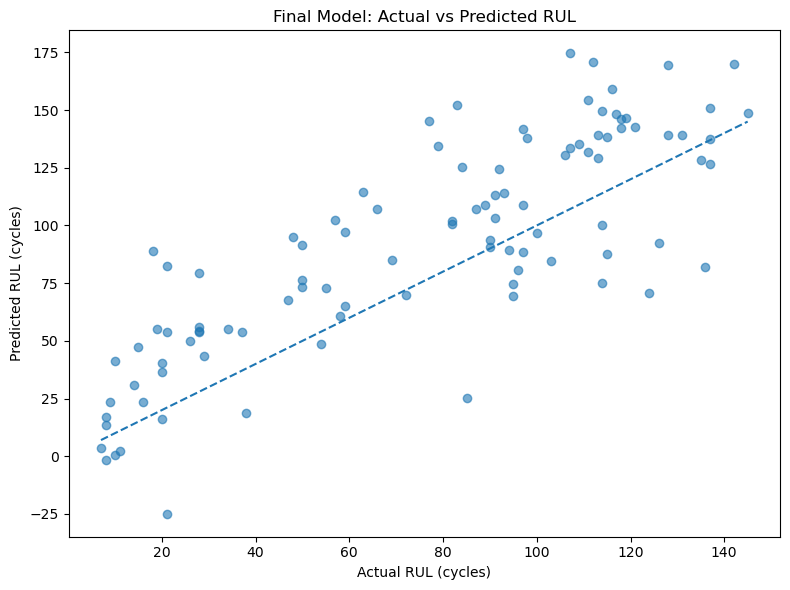

In [9]:
# Comparing actual and predicted RUL

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(y_test, test_pred, alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual RUL (cycles)")
plt.ylabel("Predicted RUL (cycles)")
plt.title("Final Model: Actual vs Predicted RUL")

plt.tight_layout()

plt.savefig(
    "../reports/figures/final_actual_vs_predicted_rul.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [10]:
# Final validation vs test performance

final_results = pd.DataFrame({
    "Dataset": ["Validation", "Unseen Test"],
    "MAE": [25.16, test_mae],
    "RMSE": [31.66, test_rmse],
    "R2": [0.768, test_r2]
})

final_results

,Dataset,MAE,RMSE,R2
0,Validation,25.160000,31.660000,0.768000
1,Unseen Test,25.975172,31.250474,0.434473


## Final Conclusion

Linear Regression was selected as the final model after comparing multiple approaches on the validation data.

The experiments included feature selection, Ridge Regression, Lasso Regression, RUL capping, Random Forest, Random Forest tuning, and Gradient Boosting.

The more complex tree-based models did not outperform the Linear Regression baseline on the validation data.

The final Linear Regression model was then retrained using all available training engines and evaluated on the completely unseen FD001 test engines.

The final test metrics provide the most important measure of how well the model generalizes to unseen engine data.

Overall, the project demonstrates that model complexity does not always lead to better performance. For this FD001 dataset and feature representation, the simpler Linear Regression model provided the strongest validation performance.